In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
%cd ../../../../CausalPriorFitting

[Errno 2] No such file or directory: '../../../../CausalPriorFitting'
/Users/arikreuter/Documents/PhD/CausalPriorFitting


In [27]:
import sys
import os
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path(os.getcwd()) / 'src'))

from priordata_processing.Datasets.InterventionalDataset import InterventionalDataset
from src.models.GraphConditionedInterventionalPFN_sklearn import GraphConditionedInterventionalPFNSklearn


## Load Configuration

In [28]:
CHECKPOINT_DIR = Path(
    "../Test_Graphs4CFMs/Graphs4CausalFoundationModels/experiments/checkpoints"
    "/lingaus/lingaus_ancestor_5node_idk_gcn_and_softatt_16751139.0"
)
checkpoint_path = str(CHECKPOINT_DIR / 'final_model_with_bardist.pt')
model_config_path = str(CHECKPOINT_DIR / 'final_model_with_bardist_config.yaml')

with open(model_config_path, 'r') as f:
    config = yaml.safe_load(f)

print('Config loaded successfully!')
print(f"Experiment: {config['experiment_name']}")
print(f"Mode: {config['mode']}")


Config loaded successfully!
Experiment: lingaus_5node_idk_gcn_and_softatt
Mode: interventional


## Extract Configurations

In [29]:
scm_config = config['scm_config']
dataset_config = config['dataset_config']
preprocessing_config = config['preprocessing_config']


In [30]:
graphintpfn = GraphConditionedInterventionalPFNSklearn(
    config_path=model_config_path,
    checkpoint_path=checkpoint_path,
    verbose=True,
)
graphintpfn.load()


[GraphConditionedInterventionalPFNSklearn] Auto-selected device: cpu
[GraphConditionedInterventionalPFNSklearn] Loading model...
  Config: ../Test_Graphs4CFMs/Graphs4CausalFoundationModels/experiments/checkpoints/lingaus/lingaus_ancestor_5node_idk_gcn_and_softatt_16751139.0/final_model_with_bardist_config.yaml
  Checkpoint: ../Test_Graphs4CFMs/Graphs4CausalFoundationModels/experiments/checkpoints/lingaus/lingaus_ancestor_5node_idk_gcn_and_softatt_16751139.0/final_model_with_bardist.pt
  BarDistribution enabled: 1000 bars, output_dim=1004
  Graph conditioning mode: partial_soft_attention
  Building model with 3 features...
  hide_fraction_matrix: variable (distribution)
  Partial graph format enabled - will propagate ancestor knowledge automatically
  Creating PartialGraphConditionedInterventionalPFN
    Mode: partial_soft_attention
  Loading checkpoint from ../Test_Graphs4CFMs/Graphs4CausalFoundationModels/experiments/checkpoints/lingaus/lingaus_ancestor_5node_idk_gcn_and_softatt_16751

## Two-Node case

In [31]:
dataset_config_twonode = dataset_config.copy()

scm_config_twonode = scm_config.copy()
scm_config_twonode['num_nodes'] = {'value': 2}
scm_config_twonode['graph_edge_prob'] = {'value': 1.0}
scm_config_twonode['exo_std_mean'] = {'value': 1.0}
scm_config_twonode['exo_std_std'] = {'value': 1e-10}
scm_config_twonode['endo_std_mean'] = {'value': 0.2}
scm_config_twonode['endo_std_std'] = {'value': 1e-10}

dataset_config_twonode['max_number_features'] = {'value': 3}


In [32]:
dataset = InterventionalDataset(
    scm_config=scm_config_twonode,
    preprocessing_config=preprocessing_config,
    dataset_config=dataset_config_twonode,
    seed=42,
    return_scm=True,
)
print(f'Dataset created with {len(dataset)} samples')


Dataset created with 100000000 samples


In [33]:
def run_graph_check(dataset, model, dataset_idx, adj_values, title):
    X_obs, T_obs, Y_obs, X_intv, T_intv, Y_intv, adj, scm, processor, _ = dataset[dataset_idx]
    adj[0, 1], adj[1, 0] = adj_values

    print(f'--- {title} ---')
    print('Ancestor matrix:'); print(adj)
    scm.dag.draw()
    print(f'Intervened feature: {processor.intervened_feature}')
    print(f'Target feature: {processor.selected_target_feature}')

    t_intv = T_intv
    kwargs = dict(
        X_obs=X_obs.numpy(), T_obs=T_obs.numpy(), Y_obs=Y_obs.numpy(),
        X_intv=X_intv.numpy(), T_intv=t_intv.numpy(),
        adjacency_matrix=adj.numpy(),
    )

    pred_mean = model.predict(**kwargs)
    plt.figure(figsize=(8, 8))
    plt.scatter(Y_intv.numpy(), pred_mean, alpha=0.6, label='Predictions')
    lo = min(Y_intv.numpy().min(), pred_mean.min())
    hi = max(Y_intv.numpy().max(), pred_mean.max())
    plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Identity line')
    plt.xlabel('True Y_intv'); plt.ylabel('Predicted Y')
    plt.title(f'{title} \u2014 Predictions vs True')
    plt.legend(); plt.grid(True, alpha=0.3); plt.axis('equal')
    plt.show()

    pred_samples = model.predict(**kwargs, prediction_type='sample', num_samples=1000)
    n = pred_samples.shape[0]
    t_rep = torch.tile(t_intv, (n, 1)).flatten()
    s_flat = torch.tensor(pred_samples.flatten())
    y_lo = torch.quantile(s_flat, 0.025).item() * 1.5
    y_hi = torch.quantile(s_flat, 0.975).item() * 1.5

    plt.figure(figsize=(8, 8))
    plt.scatter(t_rep.numpy(), s_flat.numpy(), alpha=0.1, s=0.1, label='Posterior samples')
    plt.xlabel('T_intv'); plt.ylabel('Predicted Y')
    plt.title(f'{title} \u2014 Posterior Predictive Samples')
    plt.ylim(y_lo, y_hi); plt.legend()
    plt.show()


### T -> Y, We don't tell the model the relationship between T and Y

--- Unknown relationship ---
Ancestor matrix:
tensor([[-1.,  0., -1., -1., -1.],
        [ 0., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.]])


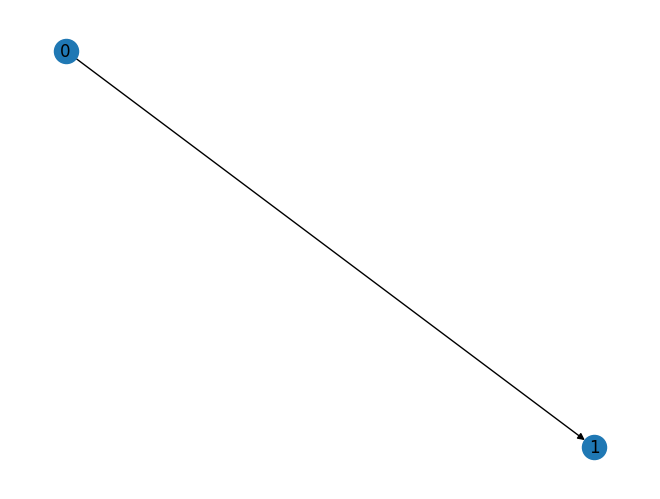

Intervened feature: 1
Target feature: 0


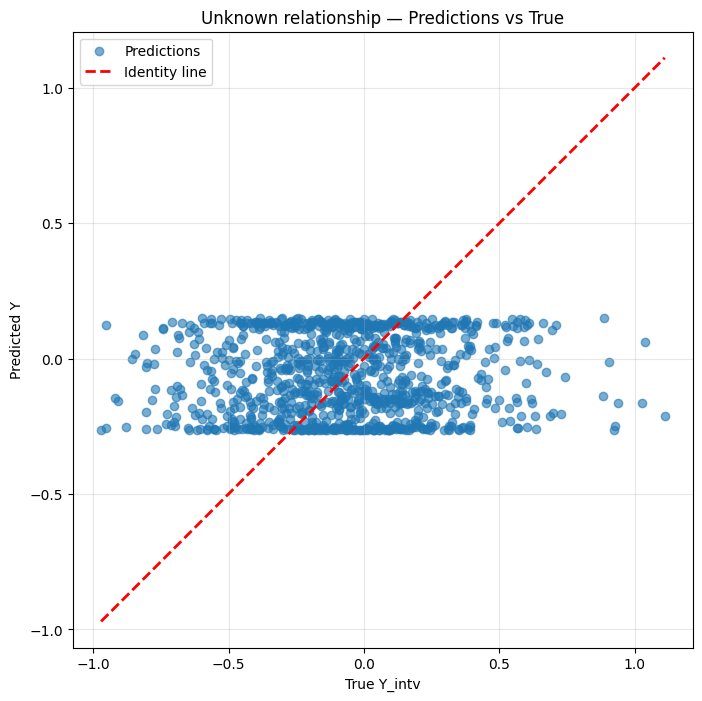

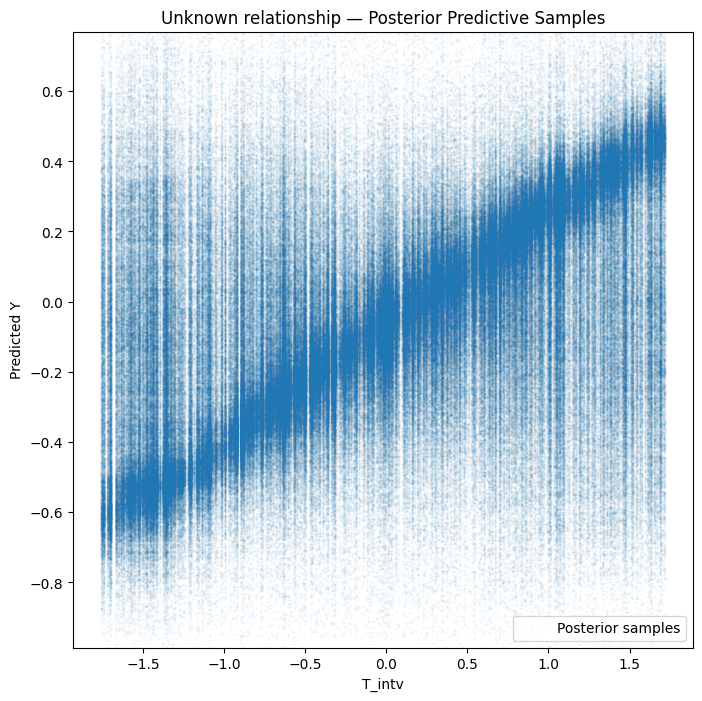

In [34]:
run_graph_check(dataset, graphintpfn, 0, (0.0, 0.0), 'Unknown relationship')

### T -> Y, We tell the mdoel T -> Y

--- T → Y ---
Ancestor matrix:
tensor([[-1.,  1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.]])


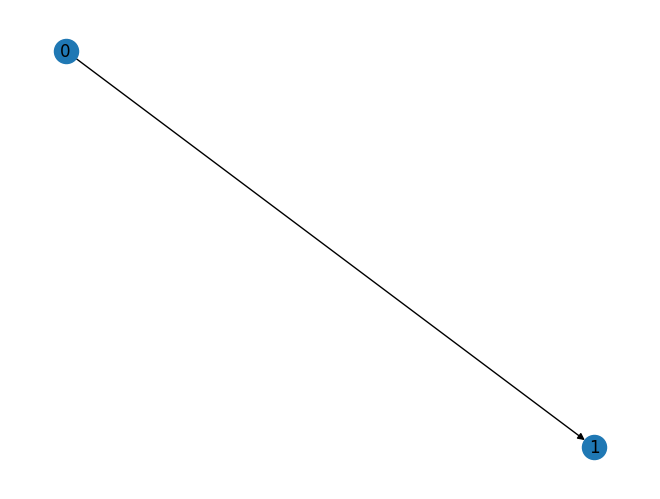

Intervened feature: 1
Target feature: 0


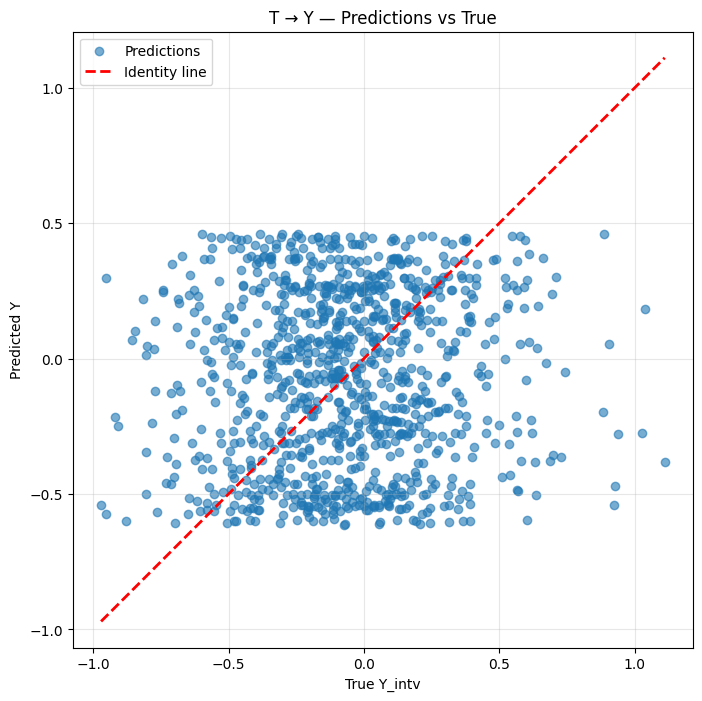

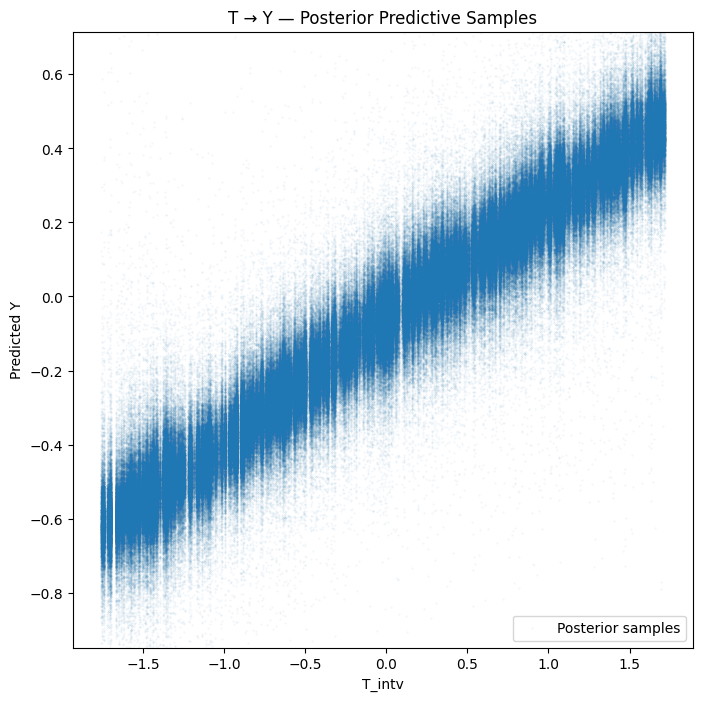

In [35]:
run_graph_check(dataset, graphintpfn, 0, (1.0, -1.0), 'T \u2192 Y')

### T -> Y, We tell the mdoel Y -> T

--- Y → T ---
Ancestor matrix:
tensor([[-1., -1., -1., -1., -1.],
        [ 1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.]])


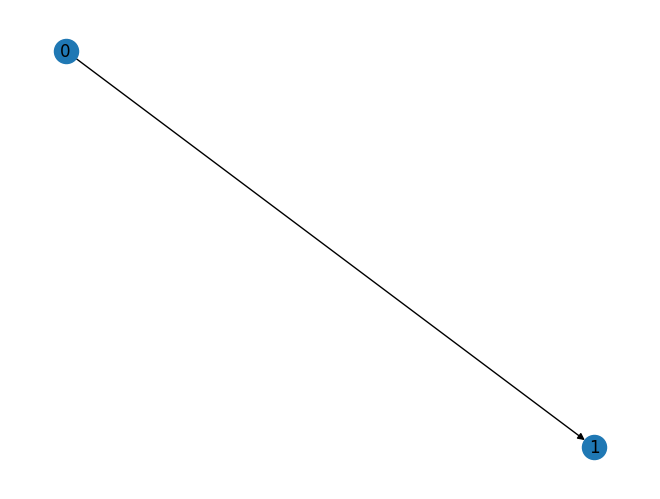

Intervened feature: 1
Target feature: 0


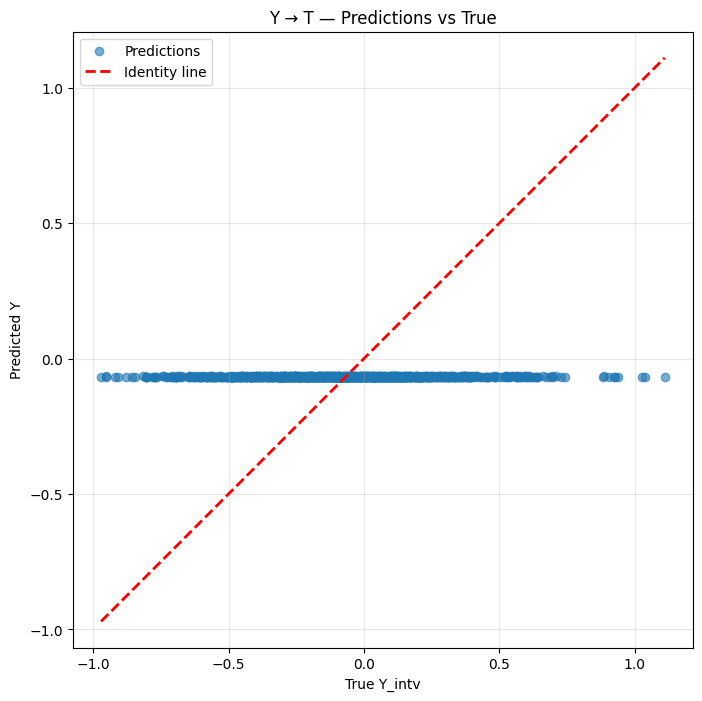

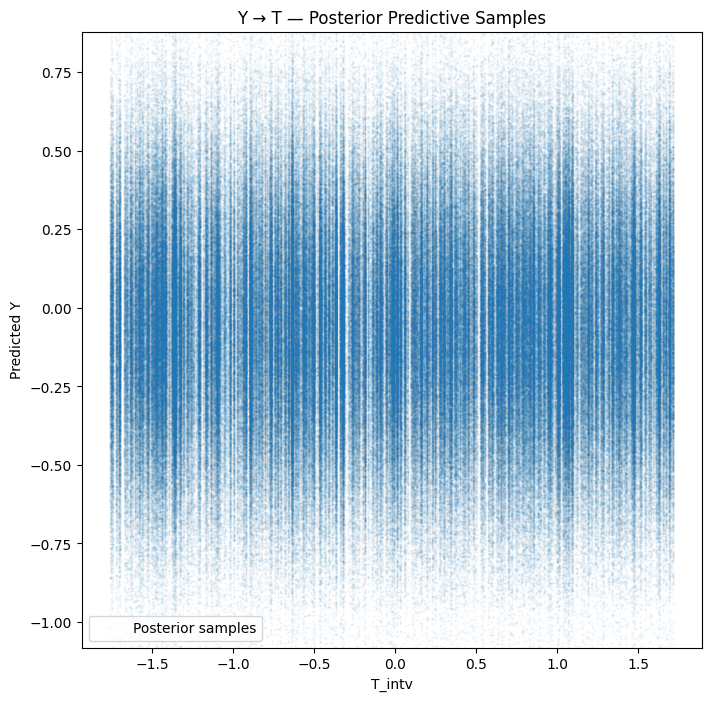

In [36]:
run_graph_check(dataset, graphintpfn, 0, (-1.0, 1.0), 'Y \u2192 T')